# 🛰️ Pronóstico de contaminación lumínica — Buenos Aires (2012 → 2035)

**StarMap BA · análisis de datos** — por Joaquín Rao

En el [notebook 01](01_contaminacion_luminica_ba.ipynb) validé los ratings de
cielo oscuro contra el satélite (correlación de Spearman **+0.76**). Acá doy el
paso siguiente: **¿cómo viene cambiando el cielo oscuro de la Provincia, y qué
va a quedar en 10 años?**

Uso cuatro años del producto **VIIRS** de luz nocturna (2012, 2016, 2020 y 2024)
recortados a la Provincia de Buenos Aires, mido la tendencia **celda por celda**
y la proyecto a 2035.

> ⚠️ **Es una proyección de tendencia, no un pronóstico exacto.** Extrapolar 10
> años es incierto, y la serie mezcla VNL v2.1 (2012–2020) con v2.2 (2024). La
> idea es leer la *dirección* del cambio, no clavar un número.

In [1]:
%matplotlib inline
from pathlib import Path
import json
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

DATA = Path("data")
YEARS = [2012, 2016, 2020, 2024]
DARK = 0.5  # nW/cm²/sr — umbral de "cielo oscuro" (~Bortle 3 o mejor)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})

## 1. Los datos: cuatro fotos en el tiempo

Cada archivo es el compuesto anual de radiancia (`median_masked`) ya recortado a
la Provincia con el mismo polígono del IGN que usa la app. Los cuatro están en la
**misma grilla** (~500 m), así que cada celda se puede comparar año contra año.

In [2]:
stack, bounds = [], None
for y in YEARS:
    with rasterio.open(DATA / f"viirs_ba_{y}.tif") as ds:
        stack.append(ds.read(1).astype("float64"))
        bounds = ds.bounds
stack = np.array(stack)            # (4, alto, ancho)
H, W = stack.shape[1:]
print(f"{len(YEARS)} años cargados | grilla {W}x{H} px | alineados: {stack.shape}")

4 años cargados | grilla 1614x1861 px | alineados: (4, 1861, 1614)


## 2. ¿Cuánto cielo oscuro queda, año a año?

Defino "cielo oscuro" como las celdas por debajo de `DARK = 0.5` nW/cm²/sr (lo que
el satélite ve, en la práctica, como noche sin contaminar). Miro qué porcentaje de
la Provincia cae ahí cada año.

In [3]:
def dark_pct(a):
    return 100.0 * (a < DARK).mean()

for i, y in enumerate(YEARS):
    lit = stack[i][stack[i] > 0]
    print(f"{y}: {dark_pct(stack[i].ravel()):.1f}% oscuro "
          f"| px con luz {lit.size:,} | mediana de los iluminados {np.median(lit):.2f}")

2012: 97.2% oscuro | px con luz 136,023 | mediana de los iluminados 0.92
2016: 96.8% oscuro | px con luz 143,720 | mediana de los iluminados 1.02
2020: 96.1% oscuro | px con luz 146,874 | mediana de los iluminados 1.27
2024: 95.2% oscuro | px con luz 165,750 | mediana de los iluminados 1.27


## 3. La tendencia, celda por celda

Para cada celda tengo cuatro valores en el tiempo. Le ajusto una **recta**
(regresión lineal por mínimos cuadrados: `radiancia = a + b·año`) y me quedo con la
**pendiente `b`** = cuánta luz suma por año. Después estiro esa recta 11 años, hasta
2035.

Es deliberadamente simple: con 4 puntos en el tiempo, una recta es el techo
honesto. El único "factor" es la inercia que ya muestra cada lugar — no hay
supuestos sobre urbanización, población ni recambio a LED.

In [4]:
x = np.array(YEARS, dtype="float64")
xb = x - x.mean()
Y = stack.reshape(len(YEARS), -1)

# OLS vectorizado por píxel: pendiente = cov(año, rad) / var(año)
slope = (xb[:, None] * (Y - Y.mean(0))).sum(0) / (xb ** 2).sum()  # nW por año
rad2024 = Y[-1]
rad2035 = np.clip(rad2024 + slope * (2035 - 2024), 0, None)

lit2012, lit2024 = (stack[0] > 0).sum(), (stack[-1] > 0).sum()
print(f"Cielo oscuro: 2024 {dark_pct(rad2024):.1f}%  ->  2035 {dark_pct(rad2035):.1f}% "
      f"(proyectado)")
print(f"Huella iluminada 2012 -> 2024: +{100 * (lit2024 - lit2012) / lit2012:.0f}%")

Cielo oscuro: 2024 95.2%  ->  2035 94.6% (proyectado)
Huella iluminada 2012 -> 2024: +22%


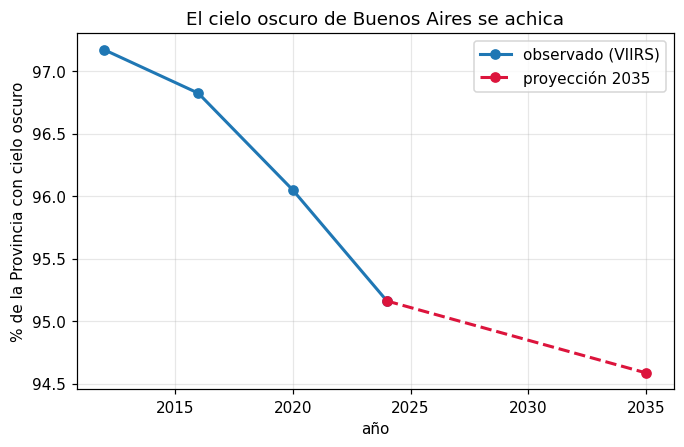

In [5]:
dark_series = [dark_pct(stack[i].ravel()) for i in range(len(YEARS))]
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(YEARS, dark_series, "o-", lw=2, label="observado (VIIRS)")
ax.plot([2024, 2035], [dark_series[-1], dark_pct(rad2035)], "o--", color="crimson",
        lw=2, label="proyección 2035")
ax.set(xlabel="año", ylabel="% de la Provincia con cielo oscuro",
       title="El cielo oscuro de Buenos Aires se achica")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 4. Antes y después: 2012 vs 2024

Las dos puntas de la serie, con la misma escala logarítmica. Se ve cómo el Gran
Buenos Aires y las ciudades del interior se "encienden" con más fuerza, mientras
el campo sigue mayormente oscuro.

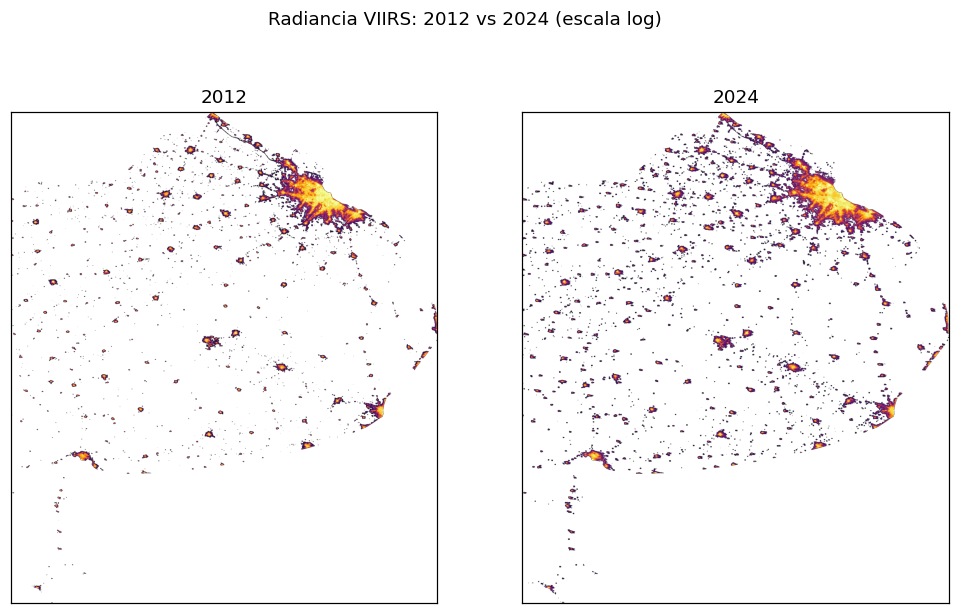

In [6]:
ext = [bounds.left, bounds.right, bounds.bottom, bounds.top]
norm = LogNorm(vmin=0.3, vmax=float(np.nanpercentile(stack[stack > 0], 99.5)))
fig, axs = plt.subplots(1, 2, figsize=(11, 6.5))
for ax, i in zip(axs, [0, len(YEARS) - 1]):
    disp = np.where(stack[i] > 0.3, stack[i], np.nan)
    ax.imshow(disp, extent=ext, origin="upper", cmap="inferno", norm=norm)
    ax.set_title(str(YEARS[i])); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Radiancia VIIRS: 2012 vs 2024 (escala log)")
plt.show()

## 5. ¿Dónde crece la luz?

El mapa de la **pendiente** (`b`): brillante = la radiancia creció rápido entre
2012 y 2024. El avance se concentra en el AMBA y en los bordes de las ciudades —
exactamente donde se expande la mancha urbana.

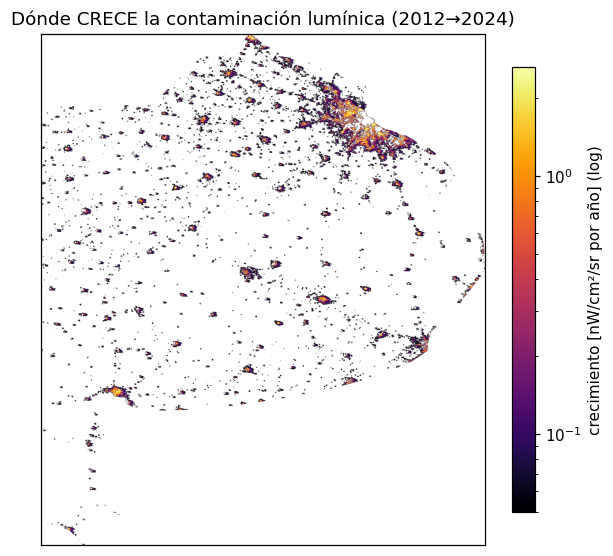

In [7]:
slope_img = slope.reshape(H, W)
disp = np.where(slope_img > 0.02, slope_img, np.nan)
fig, ax = plt.subplots(figsize=(6.5, 7.5))
im = ax.imshow(disp, extent=ext, origin="upper", cmap="inferno",
               norm=LogNorm(vmin=0.05, vmax=float(np.nanpercentile(disp, 99.5))))
ax.set_title("Dónde CRECE la contaminación lumínica (2012→2024)")
ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im, ax=ax, label="crecimiento [nW/cm²/sr por año] (log)", shrink=0.7)
plt.show()

## 6. ¿Mis puntos siguen oscuros en 2035?

Para cada uno de los 21 puntos de StarMap BA repito la cuenta: tomo la radiancia
en su entorno de 3 km (la misma metodología validada en el notebook 01), ajusto la
recta y proyecto a 2035. ¿Alguno cambia de clase Bortle para peor?

In [8]:
pts = json.loads(Path("../data/seed-points.json").read_text("utf-8"))["puntos"]
with rasterio.open(DATA / "viirs_ba_2024.tif") as ds:
    half = max(1, round((3 / 111.0) / abs(ds.transform.a)))  # ~3 km en celdas
    index = lambda lat, lng: ds.index(lng, lat)

def bortle(r):
    for thr, b in [(0.1, 2), (0.5, 3), (3, 4), (10, 5), (30, 6), (100, 7), (300, 8)]:
        if r < thr:
            return b
    return 9

def mean3(arr, r, c):
    w = arr[max(0, r - half):r + half + 1, max(0, c - half):c + half + 1]
    return float(w.mean()) if w.size else np.nan

en_riesgo, estables = [], []
for p in pts:
    r, c = index(p["lat"], p["lng"])
    if not (0 <= r < H and 0 <= c < W):
        continue
    serie = np.array([mean3(stack[i], r, c) for i in range(len(YEARS))])
    s = (xb * (serie - serie.mean())).sum() / (xb ** 2).sum()
    proj = max(0.0, serie[-1] + s * 11)
    b_now, b_fut = bortle(serie[-1]), bortle(proj)
    if b_fut > b_now:
        en_riesgo.append((p["nombre"], b_now, b_fut))
    elif p.get("categoria") != "observatorio" and b_now <= 3:
        estables.append(p["nombre"])

print(f"Puntos en riesgo (empeoran de clase Bortle para 2035): {len(en_riesgo)}")
for n, a, b in en_riesgo:
    print(f"  ⚠ {n}: Bortle {a} -> {b}")
print(f"\nEscapadas oscuras estables a 2035 (Bortle ≤ 3): {len(estables)}")
for n in estables:
    print(f"  ✓ {n}")

Puntos en riesgo (empeoran de clase Bortle para 2035): 0

Escapadas oscuras estables a 2035 (Bortle ≤ 3): 14
  ✓ Campo al sur de la Laguna de Lobos
  ✓ Campo al sur de Chascomús
  ✓ Vuelta de Obligado (San Pedro)
  ✓ Yamay Ecoturismo (Pardo, Las Flores)
  ✓ Pampa rural de Bragado
  ✓ Pampa profunda de Pila
  ✓ Sierras de Tandilia (rural al este de Tandil)
  ✓ Faro Querandí (médanos costa atlántica)
  ✓ Parque Provincial Tornquist (Sierra de la Ventana)
  ✓ Campo en Domselaar (San Vicente)
  ✓ Campo en Francisco Berra (Monte)
  ✓ Campo al sur de General Belgrano
  ✓ Campo en La Luisa (Capitán Sarmiento)
  ✓ Campo al noroeste de Chivilcoy


## Conclusiones

- **El cielo oscuro se achica, pero despacio:** de ~97% (2012) a ~95% (2024), y la
  proyección lo lleva a ~94.6% en 2035. La huella iluminada, en cambio, creció
  **+22%** en 12 años — la luz se *intensifica* y se *expande* por los bordes.
- **El avance se concentra en el AMBA y las ciudades.** El interior profundo casi
  no cambia.
- **Buena noticia para el observador:** las escapadas de cielo oscuro lejanas se
  proyectan **estables** — van a seguir siendo Bortle 2–3 en 2035.

### Limitaciones (lo honesto)

- Es una **extrapolación lineal** sobre 4 puntos: sirve para la dirección, no para
  un valor exacto a 10 años.
- La serie **mezcla versiones** del producto (VNL v2.1 2012–2020 + v2.2 2024); parte
  del salto puede ser de calibración, no solo de luz real.
- El umbral de "cielo oscuro" (0.5 nW) es una convención; mover el umbral mueve los
  porcentajes (no las conclusiones).

*Dato: VIIRS VNL (EOG/NOAA, dominio público). Polígono de BA: IGN. Análisis: Joaquín Rao.*